In [3]:
import numpy as np
import GPyOpt
import os
import time
import copy
import numpy as np
import matplotlib.pyplot as plt

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader

import torchvision
from torchvision import transforms
from torchvision.datasets import ImageFolder

In [4]:
import torch
print(torch.cuda.is_available())
print(torch.cuda.get_device_name(0) if torch.cuda.is_available() else "No GPU")

False
No GPU


In [5]:
# =========================
# 0) Imports
# =========================


# =========================
# 1) Paths (EDIT THIS)
# =========================
# Sæt denne til den mappe der indeholder:
# "Reduced Training data" og "Reduced Testing data"
DATA_DIR = r"./Reduced MNIST Data"

TRAIN_DIR = os.path.join(DATA_DIR, "Reduced Training data")
TEST_DIR  = os.path.join(DATA_DIR, "Reduced Testing data")

assert os.path.isdir(TRAIN_DIR), f"Train dir not found: {TRAIN_DIR}"
assert os.path.isdir(TEST_DIR),  f"Test dir not found: {TEST_DIR}"

# =========================
# 2) Device
# =========================
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

# =========================
# 3) Transforms
# =========================
# MNIST er typisk 28x28 grayscale. Men hvis jeres billeder allerede er 28x28,
# gør Resize intet. Hvis de er andre størrelser, tilpasses de.
transform = transforms.Compose([
    transforms.Grayscale(num_output_channels=1),   # sikrer 1 kanal
    transforms.Resize((28, 28)),
    transforms.ToTensor(),                         # [0,1]
    transforms.Normalize((0.1307,), (0.3081,))     # klassisk MNIST norm
])

# =========================
# 4) Datasets
# =========================
train_ds = ImageFolder(root=TRAIN_DIR, transform=transform)
test_ds  = ImageFolder(root=TEST_DIR, transform=transform)

# ImageFolder bruger alfabetisk sortering af klassenavne ("0","1",...,"9")
print("Class to idx:", train_ds.class_to_idx)
print("Train size:", len(train_ds), " Test size:", len(test_ds))

# =========================
# 5) DataLoaders
# =========================
BATCH_SIZE = 256
NUM_WORKERS = 2  # sæt 0 hvis Windows + issues

train_loader = DataLoader(
    train_ds, batch_size=BATCH_SIZE, shuffle=True,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

test_loader = DataLoader(
    test_ds, batch_size=BATCH_SIZE, shuffle=False,
    num_workers=NUM_WORKERS, pin_memory=(device.type == "cuda")
)

# =========================
# 6) Model (simpelt MLP)
# =========================
class SimpleMNISTMLP(nn.Module):
    def __init__(self, hidden_units=128, dropout=0.2):
        super().__init__()
        self.net = nn.Sequential(
            nn.Flatten(),                 # (B,1,28,28) -> (B,784)
            nn.Linear(28*28, hidden_units),
            nn.ReLU(),
            nn.Dropout(dropout),
            nn.Linear(hidden_units, 10)
        )

    def forward(self, x):
        return self.net(x)

# Instantiate baseline model
model = SimpleMNISTMLP(hidden_units=128, dropout=0.2).to(device)
print(model)

# =========================
# 7) Train/Eval helpers
# =========================
def accuracy_from_logits(logits, y):
    preds = logits.argmax(dim=1)
    return (preds == y).float().mean().item()

@torch.no_grad()
def evaluate(model, loader, criterion):
    model.eval()
    total_loss = 0.0
    total_correct = 0
    total_n = 0

    for x, y in loader:
        x = x.to(device, non_blocking=True)
        y = y.to(device, non_blocking=True)

        logits = model(x)
        loss = criterion(logits, y)

        total_loss += loss.item() * x.size(0)
        total_correct += (logits.argmax(dim=1) == y).sum().item()
        total_n += x.size(0)

    return total_loss / total_n, total_correct / total_n

def train(model, train_loader, test_loader, lr=1e-3, weight_decay=0.0, epochs=3):
    criterion = nn.CrossEntropyLoss()
    optimizer = optim.Adam(model.parameters(), lr=lr, weight_decay=weight_decay)

    best_model = copy.deepcopy(model.state_dict())
    best_acc = -1.0

    history = {
        "train_loss": [],
        "train_acc": [],
        "test_loss": [],
        "test_acc": []
    }

    t0 = time.time()

    for epoch in range(1, epochs + 1):
        model.train()

        running_loss = 0.0
        running_correct = 0
        running_n = 0

        for x, y in train_loader:
            x = x.to(device, non_blocking=True)
            y = y.to(device, non_blocking=True)

            optimizer.zero_grad()
            logits = model(x)
            loss = criterion(logits, y)
            loss.backward()
            optimizer.step()

            running_loss += loss.item() * x.size(0)
            running_correct += (logits.argmax(dim=1) == y).sum().item()
            running_n += x.size(0)

        train_loss = running_loss / running_n
        train_acc = running_correct / running_n

        test_loss, test_acc = evaluate(model, test_loader, criterion)

        history["train_loss"].append(train_loss)
        history["train_acc"].append(train_acc)
        history["test_loss"].append(test_loss)
        history["test_acc"].append(test_acc)

        if test_acc > best_acc:
            best_acc = test_acc
            best_model = copy.deepcopy(model.state_dict())

        print(f"Epoch {epoch:02d}/{epochs} | "
              f"train loss {train_loss:.4f}, train acc {train_acc:.4f} | "
              f"test loss {test_loss:.4f}, test acc {test_acc:.4f}")

    model.load_state_dict(best_model)
    dt = time.time() - t0
    print(f"Done. Best test acc: {best_acc:.4f} | time: {dt:.1f}s")

    return best_acc, history

# =========================
# 😎 Run baseline training
# =========================
best_acc, history = train(
    model,
    train_loader=train_loader,
    test_loader=test_loader,
    lr=1e-3,
    weight_decay=0.0,
    epochs=5
)

print("Baseline best test acc:", best_acc)

Device: cpu
Class to idx: {'0': 0, '1': 1, '2': 2, '3': 3, '4': 4, '5': 5, '6': 6, '7': 7, '8': 8, '9': 9}
Train size: 10000  Test size: 2000
SimpleMNISTMLP(
  (net): Sequential(
    (0): Flatten(start_dim=1, end_dim=-1)
    (1): Linear(in_features=784, out_features=128, bias=True)
    (2): ReLU()
    (3): Dropout(p=0.2, inplace=False)
    (4): Linear(in_features=128, out_features=10, bias=True)
  )
)
Epoch 01/5 | train loss 0.7859, train acc 0.7718 | test loss 0.3017, test acc 0.9130
Epoch 02/5 | train loss 0.3345, train acc 0.8978 | test loss 0.2434, test acc 0.9285
Epoch 03/5 | train loss 0.2697, train acc 0.9190 | test loss 0.2088, test acc 0.9415
Epoch 04/5 | train loss 0.2295, train acc 0.9312 | test loss 0.1880, test acc 0.9435
Epoch 05/5 | train loss 0.1945, train acc 0.9418 | test loss 0.1725, test acc 0.9510
Done. Best test acc: 0.9510 | time: 82.8s
Baseline best test acc: 0.951


In [6]:
def run_one_training(lr, dropout, hidden_units, epochs=2):
    model = SimpleMNISTMLP(
        hidden_units=int(hidden_units),
        dropout=float(dropout)
    ).to(device)

    best_acc, _ = train(
        model,
        train_loader=train_loader,
        test_loader=test_loader,
        lr=float(lr),
        epochs=epochs
    )

    return best_acc

#### objektiv funvkion

In [7]:
def objective_gpyopt(X):
    results = []

    for x in X:
        lr = x[0]
        dropout = x[1]
        hidden = int(x[2])

        acc = run_one_training(lr, dropout, hidden, epochs=2)

        err = 1.0 - acc   # GPyOpt minimerer!
        results.append([err])

        print(f"lr={lr:.5f}, dropout={dropout:.3f}, hidden={hidden}, acc={acc:.4f}")

    return np.array(results)

### Search space

In [8]:
# kan vi ændre på hvis det er:
domain = [
    {'name': 'lr', 'type': 'continuous', 'domain': (1e-4, 1e-1)},
    {'name': 'dropout', 'type': 'continuous', 'domain': (0.0, 0.5)},
    {'name': 'hidden_units', 'type': 'discrete', 'domain': (32, 64, 128, 256, 512)}
]

### GPyOpt og acquisition functions

### EI Test kun med 25 iterations. manuel kode blok. de tre acqi funcs køres længere nede

In [9]:
bo = GPyOpt.methods.BayesianOptimization(
    f=objective_gpyopt,
    domain=domain,
    acquisition_type='EI',   # EI / MPI / LCB
    initial_design_numdata=5
)

bo.run_optimization(max_iter=20)

Epoch 01/2 | train loss 30.8289, train acc 0.4526 | test loss 1.3125, test acc 0.5760
Epoch 02/2 | train loss 1.3073, train acc 0.5751 | test loss 0.9142, test acc 0.6865
Done. Best test acc: 0.6865 | time: 26.0s
lr=0.07816, dropout=0.202, hidden=512, acc=0.6865
Epoch 01/2 | train loss 5.8808, train acc 0.4100 | test loss 1.1740, test acc 0.6240
Epoch 02/2 | train loss 1.1293, train acc 0.6243 | test loss 1.1210, test acc 0.6480
Done. Best test acc: 0.6480 | time: 27.2s
lr=0.07973, dropout=0.081, hidden=128, acc=0.6480
Epoch 01/2 | train loss 20.2119, train acc 0.2441 | test loss 1.9198, test acc 0.2735
Epoch 02/2 | train loss 1.9266, train acc 0.3076 | test loss 2.2058, test acc 0.3305
Done. Best test acc: 0.3305 | time: 26.9s
lr=0.09455, dropout=0.201, hidden=256, acc=0.3305
Epoch 01/2 | train loss 3.5534, train acc 0.6114 | test loss 0.4787, test acc 0.8580
Epoch 02/2 | train loss 0.7861, train acc 0.7563 | test loss 0.3109, test acc 0.9175
Done. Best test acc: 0.9175 | time: 27.4s


### Results from EI testrun

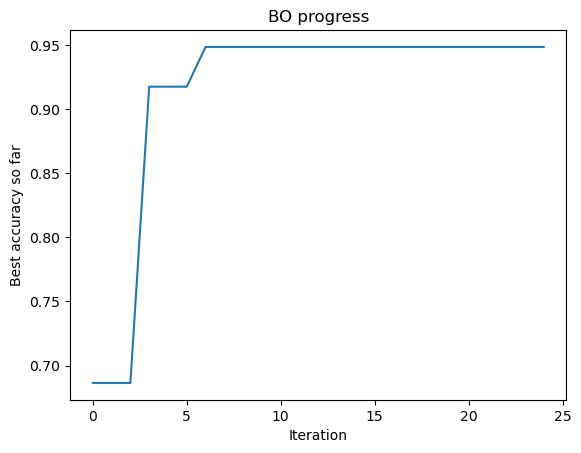

In [10]:


errors = bo.Y.flatten()
best_so_far = np.minimum.accumulate(errors)
best_acc = 1 - best_so_far

plt.plot(best_acc)
plt.xlabel("Iteration")
plt.ylabel("Best accuracy so far")
plt.title("BO progress")
plt.show()

In [9]:
bo_ei = bo  

NameError: name 'bo' is not defined

In [10]:
import numpy as np

def best_acc_curve_from_bo(bo):
    errors = bo.Y.flatten()                      # objective values = error = 1-acc
    best_err = np.minimum.accumulate(errors)     # best so far (min error)
    return 1.0 - best_err                        # convert back to accuracy

### Random baseline

In [11]:
import numpy as np


DROPOUT_MAX = 0.6  
HIDDEN_CHOICES = [32, 64, 128, 256, 512]

def sample_random_params_old():
    # lr uniform i (1e-4, 1e-1) (samme som din domain)
    lr = np.random.uniform(1e-4, 1e-1)
    dropout = np.random.uniform(0.0, DROPOUT_MAX)
    hidden = int(np.random.choice(HIDDEN_CHOICES))
    return lr, dropout, hidden

def run_random_search(n_evals=25, seed=0, epochs=2):
    np.random.seed(seed)
    errs = []

    for i in range(n_evals):
        lr, dropout, hidden = sample_random_params_old()
        acc = run_one_training(lr, dropout, hidden, epochs=epochs)
        err = 1.0 - acc
        errs.append(err)
        print(f"[RND {i+1:02d}/{n_evals}] lr={lr:.5g}, dropout={dropout:.3f}, hidden={hidden} -> acc={acc:.4f}")

    errs = np.array(errs)
    best_err = np.minimum.accumulate(errs)
    best_acc = 1.0 - best_err
    return best_acc

In [12]:
# kør for at få random baseline med 25 iterations:
rand_curve = run_random_search(n_evals=25, seed=0, epochs=2)

Epoch 01/2 | train loss 7.5953, train acc 0.4652 | test loss 0.8622, test acc 0.7275
Epoch 02/2 | train loss 1.2607, train acc 0.5953 | test loss 0.6978, test acc 0.7605
Done. Best test acc: 0.7605 | time: 30.8s
[RND 01/25] lr=0.054926, dropout=0.429, hidden=256 -> acc=0.7605
Epoch 01/2 | train loss 12.6479, train acc 0.2819 | test loss 1.7850, test acc 0.3230
Epoch 02/2 | train loss 1.9773, train acc 0.2893 | test loss 1.5121, test acc 0.4405
Done. Best test acc: 0.4405 | time: 30.7s
[RND 02/25] lr=0.085809, dropout=0.508, hidden=256 -> acc=0.4405
Epoch 01/2 | train loss 2.2053, train acc 0.3060 | test loss 1.4225, test acc 0.4050
Epoch 02/2 | train loss 1.5725, train acc 0.4310 | test loss 1.0801, test acc 0.6050
Done. Best test acc: 0.6050 | time: 30.6s
[RND 03/25] lr=0.064625, dropout=0.263, hidden=32 -> acc=0.6050
Epoch 01/2 | train loss 3.6520, train acc 0.1555 | test loss 2.1558, test acc 0.1605
Epoch 02/2 | train loss 2.1926, train acc 0.1542 | test loss 2.0810, test acc 0.1930

### MPI, EI and LCB runs

In [13]:
import GPyOpt

def run_bo(acq="EI", max_iter=20, init=5, seed=0):
    np.random.seed(seed)
    bo = GPyOpt.methods.BayesianOptimization(
        f=objective_gpyopt,
        domain=domain,
        acquisition_type=acq,
        initial_design_numdata=init
    )
    bo.run_optimization(max_iter=max_iter)
    return bo

In [14]:
# kør for at få BO med MPI acqisitin:

bo_ei  = run_bo(acq="EI",  max_iter=20, init=5, seed=0)

Epoch 01/2 | train loss 38.2746, train acc 0.4669 | test loss 1.2680, test acc 0.5705
Epoch 02/2 | train loss 1.1410, train acc 0.6070 | test loss 0.8510, test acc 0.7235
Done. Best test acc: 0.7235 | time: 31.2s
lr=0.08474, dropout=0.136, hidden=512, acc=0.7235
Epoch 01/2 | train loss 2.2057, train acc 0.3688 | test loss 1.2003, test acc 0.5650
Epoch 02/2 | train loss 1.4595, train acc 0.4787 | test loss 0.9228, test acc 0.6660
Done. Best test acc: 0.6660 | time: 30.9s
lr=0.06239, dropout=0.239, hidden=32, acc=0.6660
Epoch 01/2 | train loss 4.6986, train acc 0.4680 | test loss 0.7526, test acc 0.7665
Epoch 02/2 | train loss 1.0451, train acc 0.6593 | test loss 0.4085, test acc 0.8950
Done. Best test acc: 0.8950 | time: 30.5s
lr=0.03850, dropout=0.406, hidden=256, acc=0.8950
Epoch 01/2 | train loss 2.7475, train acc 0.6332 | test loss 0.4599, test acc 0.8810
Epoch 02/2 | train loss 0.5689, train acc 0.8264 | test loss 0.3192, test acc 0.9175
Done. Best test acc: 0.9175 | time: 38.8s
lr

In [15]:
#kør for at få BO med MPI acqisition
bo_mpi = run_bo(acq="MPI", max_iter=20, init=5, seed=0)

Epoch 01/2 | train loss 23.5335, train acc 0.4401 | test loss 1.1660, test acc 0.5610
Epoch 02/2 | train loss 1.2960, train acc 0.5593 | test loss 1.1810, test acc 0.5825
Done. Best test acc: 0.5825 | time: 48.1s
lr=0.08474, dropout=0.136, hidden=512, acc=0.5825
Epoch 01/2 | train loss 2.4150, train acc 0.3387 | test loss 1.2040, test acc 0.5685
Epoch 02/2 | train loss 1.2989, train acc 0.5606 | test loss 0.9055, test acc 0.7040
Done. Best test acc: 0.7040 | time: 46.7s
lr=0.06239, dropout=0.239, hidden=32, acc=0.7040
Epoch 01/2 | train loss 3.8189, train acc 0.5096 | test loss 0.8284, test acc 0.7820
Epoch 02/2 | train loss 1.0809, train acc 0.6428 | test loss 0.6627, test acc 0.8090
Done. Best test acc: 0.8090 | time: 48.0s
lr=0.03850, dropout=0.406, hidden=256, acc=0.8090
Epoch 01/2 | train loss 2.3873, train acc 0.6533 | test loss 0.4083, test acc 0.8790
Epoch 02/2 | train loss 0.5366, train acc 0.8412 | test loss 0.3380, test acc 0.9110
Done. Best test acc: 0.9110 | time: 50.3s
lr

In [16]:
#køer for at fo BO med LCB acquisition:
bo_lcb = run_bo(acq="LCB", max_iter=20, init=5, seed=0)

Epoch 01/2 | train loss 39.4460, train acc 0.4369 | test loss 1.4527, test acc 0.4895
Epoch 02/2 | train loss 1.3733, train acc 0.4980 | test loss 1.1856, test acc 0.5610
Done. Best test acc: 0.5610 | time: 25.4s
lr=0.08474, dropout=0.136, hidden=512, acc=0.5610
Epoch 01/2 | train loss 2.7418, train acc 0.1615 | test loss 2.0709, test acc 0.1860
Epoch 02/2 | train loss 2.1042, train acc 0.1938 | test loss 1.7988, test acc 0.3030
Done. Best test acc: 0.3030 | time: 25.9s
lr=0.06239, dropout=0.239, hidden=32, acc=0.3030
Epoch 01/2 | train loss 3.3203, train acc 0.5563 | test loss 0.5970, test acc 0.8140
Epoch 02/2 | train loss 0.9601, train acc 0.6988 | test loss 0.4604, test acc 0.8680
Done. Best test acc: 0.8680 | time: 26.3s
lr=0.03850, dropout=0.406, hidden=256, acc=0.8680
Epoch 01/2 | train loss 2.0994, train acc 0.6967 | test loss 0.4051, test acc 0.8820
Epoch 02/2 | train loss 0.5150, train acc 0.8428 | test loss 0.3024, test acc 0.9060
Done. Best test acc: 0.9060 | time: 26.6s
lr

In [47]:
print(bo_ei.model.model.kern)

  Mat52.       |                value  |  constraints  |  priors
  variance     |   0.8356334975823841  |      +ve      |        
  lengthscale  |  0.03446797021990206  |      +ve      |        


In [48]:
print(bo_ei.model.model)


Name : GP regression
Objective : 34.07891739697426
Number of Parameters : 3
Number of Optimization Parameters : 3
Updates : True
Parameters:
  GP_regression.           |                value  |    constraints    |  priors
  Mat52.variance           |   0.8356334975823841  |        +ve        |        
  Mat52.lengthscale        |  0.03446797021990206  |        +ve        |        
  Gaussian_noise.variance  |    0.178872176682232  |  1e-09,1000000.0  |        


### plot of random, EI, LCB and MPI sammen

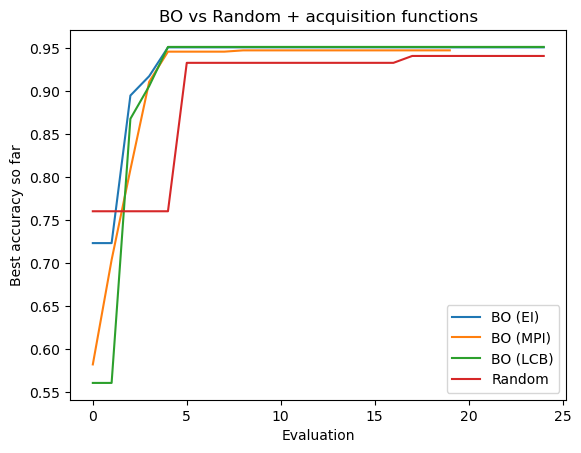

In [17]:
import matplotlib.pyplot as plt
import numpy as np

def best_acc_curve_from_bo(bo):
    errors = bo.Y.flatten()
    best_err = np.minimum.accumulate(errors)
    return 1.0 - best_err

ei_curve  = best_acc_curve_from_bo(bo_ei)
mpi_curve = best_acc_curve_from_bo(bo_mpi)
lcb_curve = best_acc_curve_from_bo(bo_lcb)

plt.figure()
plt.plot(ei_curve,  label="BO (EI)")
plt.plot(mpi_curve, label="BO (MPI)")
plt.plot(lcb_curve, label="BO (LCB)")
plt.plot(rand_curve, label="Random")

plt.xlabel("Evaluation")
plt.ylabel("Best accuracy so far")
plt.title("BO vs Random + acquisition functions")
plt.legend()
plt.show()

### samme plot anden stil

In [21]:
import numpy as np
import matplotlib.pyplot as plt

def ensure_1d(arr):
    arr = np.asarray(arr).squeeze()
    if arr.ndim != 1:
        raise ValueError(f"Expected 1D array, got shape {arr.shape}")
    return arr

def pad_to_length(y, L):
    y = ensure_1d(y)
    if len(y) == L:
        return y
    if len(y) > L:
        return y[:L]
    return np.concatenate([y, np.full(L - len(y), y[-1])])

def plot_with_markers_same_length(curves, title="Comparison", ylabel="Best accuracy so far"):
    # find max length across curves
    lengths = {name: len(ensure_1d(y)) for name, y in curves.items()}
    L = max(lengths.values())
    print("Curve lengths:", lengths, "-> using L =", L)

    x = np.arange(1, L+1)

    plt.figure(figsize=(10,6))
    for name, y in curves.items():
        y = pad_to_length(y, L)
        plt.plot(x, y, marker='o', linewidth=2, markersize=5,
                 drawstyle='steps-post', label=name)

    plt.xlabel("Iterations")
    plt.ylabel(ylabel)
    plt.title(title)
    plt.grid(True, alpha=0.3)
    plt.legend()
    plt.show()

Curve lengths: {'BO (EI)': 25, 'BO (MPI)': 20, 'BO (LCB)': 25, 'Random': 25} -> using L = 25


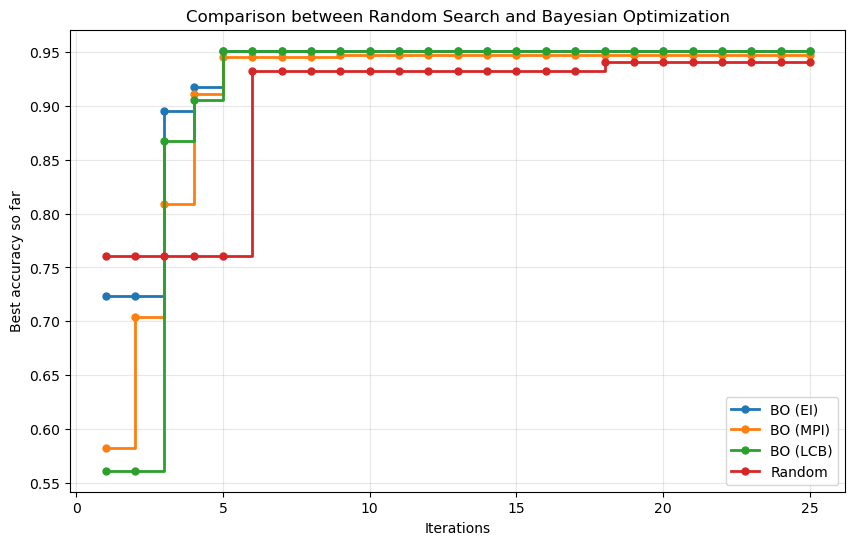

In [22]:
plot_with_markers_same_length({
    "BO (EI)": ei_curve,
    "BO (MPI)": mpi_curve,
    "BO (LCB)": lcb_curve,
    "Random": rand_curve
}, title="Comparison between Random Search and Bayesian Optimization",
   ylabel="Best accuracy so far")

### evt til at gemme results hvis vi vil:

In [ ]:
import numpy as np

def save_bo_run(bo, filename):
    np.savez(filename, X=bo.X, Y=bo.Y, x_opt=bo.x_opt, fx_opt=bo.fx_opt)

# efter du har kørt:
save_bo_run(bo_ei,  "bo_ei.npz")
save_bo_run(bo_mpi, "bo_mpi.npz")
save_bo_run(bo_lcb, "bo_lcb.npz")
np.save("rand_curve.npy", rand_curve)

### mangler visualisering af surrgoate + acqisition her

In [55]:
# import numpy as np
# import matplotlib.pyplot as plt

# # vælg hvilket BO-run du vil visualisere
# bo_to_plot = bo_ei   # eller bo_mpi / bo_lcb

# # fix den 3. dimension (hidden units)
# HIDDEN_FIXED = 128

# # grid for lr og dropout (brug jeres ranges)
# lr_min, lr_max = 1e-4, 1e-1
# do_min, do_max = 0.0, 0.6

# N_LR = 80
# N_DO = 80

# lr_grid = np.linspace(lr_min, lr_max, N_LR)
# do_grid = np.linspace(do_min, do_max, N_DO)

# LR, DO = np.meshgrid(lr_grid, do_grid, indexing='ij')  # LR shape (N_LR,N_DO)

# # lav query points Xq shape (Npoints, 3)
# Xq = np.column_stack([
#     LR.ravel(),
#     DO.ravel(),
#     np.full(LR.size, HIDDEN_FIXED)
# ])

# print("Xq shape:", Xq.shape)

# # hent den underliggende GPy model (surrogate)
# gpy_model = bo_to_plot.model.model  # GPy regression model
# print("GPy model:", type(gpy_model))

# # hent acquisition objektet
# acq = bo_to_plot.acquisition
# print("Acquisition type:", bo_to_plot.acquisition_type)




import numpy as np
import matplotlib.pyplot as plt

# vælg hvilket BO-run du vil visualisere
bo_to_plot = bo_mpi   # eller bo_mpi / bo_lcb

# fix den 3. dimension (hidden units)
HIDDEN_FIXED = 256

# grid for lr og dropout (brug jeres ranges)
lr_min, lr_max = 1e-4, 1e-1
do_min, do_max = 0.0, 0.6

N_LR = 80
N_DO = 80

lr_grid = np.linspace(lr_min, lr_max, N_LR)
do_grid = np.linspace(do_min, do_max, N_DO)

LR, DO = np.meshgrid(lr_grid, do_grid, indexing='ij')  # LR shape (N_LR,N_DO)

# lav query points Xq shape (Npoints, 3)
Xq = np.column_stack([
    LR.ravel(),
    DO.ravel(),
    np.full(LR.size, HIDDEN_FIXED)
])

print("Xq shape:", Xq.shape)

# hent den underliggende GPy model (surrogate)
gpy_model = bo_to_plot.model.model  # GPy regression model
print("GPy model:", type(gpy_model))

# hent acquisition objektet
acq = bo_to_plot.acquisition
print("Acquisition type:", bo_to_plot.acquisition_type)

# --- NEW: hent evaluerede punkter (hvis tilgængeligt) ---
X_obs = getattr(bo_to_plot, "X", None)
Y_obs = getattr(bo_to_plot, "Y", None)

# filter kun punkter med hidden = HIDDEN_FIXED (så scatter matcher dit slice)
x_scatter = y_scatter = None
if X_obs is not None:
    X_obs = np.asarray(X_obs)
    mask = np.isclose(X_obs[:, 2], HIDDEN_FIXED)
    X_slice = X_obs[mask]
    if X_slice.size > 0:
        x_scatter = X_slice[:, 0]  # lr
        y_scatter = X_slice[:, 1]  # dropout
        print(f"Overlay points in this slice: {len(X_slice)}")
    else:
        print("No observed points match hidden slice; scatter overlay disabled.")
else:
    print("bo_to_plot.X not found; scatter overlay disabled.")

Xq shape: (6400, 3)
GPy model: <class 'GPy.models.gp_regression.GPRegression'>
Acquisition type: MPI
Overlay points in this slice: 18


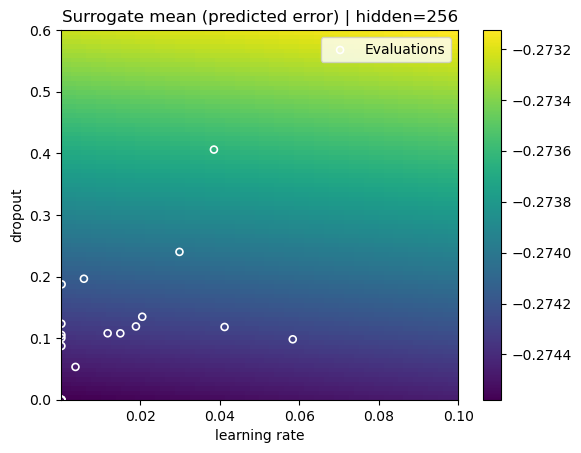

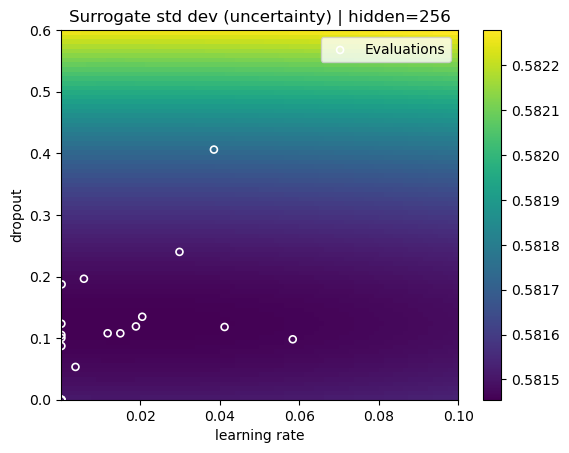

In [56]:
# # GP surrogate prediction (mean + var) for objective (error = 1-acc)
# mu, var = gpy_model.predict(Xq)              # each shape (Npoints,1)
# std = np.sqrt(np.clip(var, 1e-12, None))

# mu_img = mu.reshape(N_LR, N_DO)
# std_img = std.reshape(N_LR, N_DO)

# plt.figure()
# plt.imshow(mu_img.T, origin='lower',
#            extent=[lr_min, lr_max, do_min, do_max],
#            aspect='auto')
# plt.colorbar()
# plt.xlabel('learning rate')
# plt.ylabel('dropout')
# plt.title(f'Surrogate mean (predicted error) | hidden={HIDDEN_FIXED}')
# plt.show()

# plt.figure()
# plt.imshow(std_img.T, origin='lower',
#            extent=[lr_min, lr_max, do_min, do_max],
#            aspect='auto')
# plt.colorbar()
# plt.xlabel('learning rate')
# plt.ylabel('dropout')
# plt.title(f'Surrogate std dev (uncertainty) | hidden={HIDDEN_FIXED}')
# plt.show()

# GP surrogate prediction (mean + var) for objective (error = 1-acc)
mu, var = gpy_model.predict(Xq)              # each shape (Npoints,1)
std = np.sqrt(np.clip(var, 1e-12, None))

mu_img = mu.reshape(N_LR, N_DO)
std_img = std.reshape(N_LR, N_DO)

# --- NEW: fast colorscale (per map-type) ---
mu_vmin, mu_vmax = float(mu.min()), float(mu.max())
std_vmin, std_vmax = float(std.min()), float(std.max())

# NOTE: extent skal matche axes: x=lr, y=dropout
extent = [lr_min, lr_max, do_min, do_max]
cmap = "viridis"  # samme palette i alle tre figurer

plt.figure()
plt.imshow(mu_img.T, origin='lower',
           extent=extent,
           aspect='auto',
           cmap=cmap,
           vmin=mu_vmin, vmax=mu_vmax)
plt.colorbar()
if x_scatter is not None:
    plt.scatter(x_scatter, y_scatter, s=25, marker='o',
                facecolors='none', edgecolors='white', linewidths=1.2,
                label='Evaluations')
    plt.legend(loc='best')
plt.xlabel('learning rate')
plt.ylabel('dropout')
plt.title(f'Surrogate mean (predicted error) | hidden={HIDDEN_FIXED}')
plt.show()

plt.figure()
plt.imshow(std_img.T, origin='lower',
           extent=extent,
           aspect='auto',
           cmap=cmap,
           vmin=std_vmin, vmax=std_vmax)
plt.colorbar()
if x_scatter is not None:
    plt.scatter(x_scatter, y_scatter, s=25, marker='o',
                facecolors='none', edgecolors='white', linewidths=1.2,
                label='Evaluations')
    plt.legend(loc='best')
plt.xlabel('learning rate')
plt.ylabel('dropout')
plt.title(f'Surrogate std dev (uncertainty) | hidden={HIDDEN_FIXED}')
plt.show()

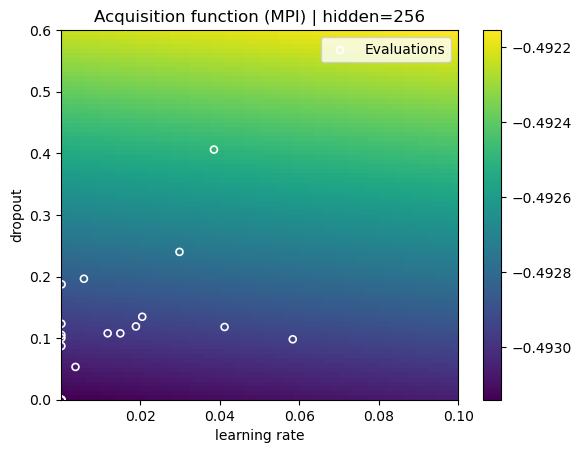

In [57]:
# acq_vals = acq.acquisition_function(Xq)  # (Npoints,1) eller (Npoints,)
# acq_vals = np.asarray(acq_vals).reshape(-1)

# acq_img = acq_vals.reshape(N_LR, N_DO)

# plt.figure()
# plt.imshow(acq_img.T, origin='lower',
#            extent=[lr_min, lr_max, do_min, do_max],
#            aspect='auto')
# plt.colorbar()
# plt.xlabel('learning rate')
# plt.ylabel('dropout')
# plt.title(f'Acquisition function ({bo_to_plot.acquisition_type}) | hidden={HIDDEN_FIXED}')
# plt.show()

acq_vals = acq.acquisition_function(Xq)  # (Npoints,1) eller (Npoints,)
acq_vals = np.asarray(acq_vals).reshape(-1)

acq_img = acq_vals.reshape(N_LR, N_DO)

# --- NEW: fast colorscale for acquisition map ---
acq_vmin, acq_vmax = float(acq_vals.min()), float(acq_vals.max())

extent = [lr_min, lr_max, do_min, do_max]
cmap = "viridis"

plt.figure()
plt.imshow(acq_img.T, origin='lower',
           extent=extent,
           aspect='auto',
           cmap=cmap,
           vmin=acq_vmin, vmax=acq_vmax)
plt.colorbar()
if x_scatter is not None:
    plt.scatter(x_scatter, y_scatter, s=25, marker='o',
                facecolors='none', edgecolors='white', linewidths=1.2,
                label='Evaluations')
    plt.legend(loc='best')
plt.xlabel('learning rate')
plt.ylabel('dropout')
plt.title(f'Acquisition function ({bo_to_plot.acquisition_type}) | hidden={HIDDEN_FIXED}')
plt.show()

In [41]:
print("len(X), len(Y):", len(bo_to_plot.X), len(bo_to_plot.Y))
print("hidden counts:", np.unique(bo_to_plot.X[:,2], return_counts=True))
print("lr min/max, do min/max:", (bo_to_plot.X[:,0].min(), bo_to_plot.X[:,0].max()),
                                 (bo_to_plot.X[:,1].min(), bo_to_plot.X[:,1].max()))

len(X), len(Y): 25 25
hidden counts: (array([ 32.,  64., 128., 256., 512.]), array([ 1,  5,  4, 14,  1], dtype=int64))
lr min/max, do min/max: (0.0001, 0.1) (0.0, 0.5)


In [45]:
print(acq.acquisition_function(
    np.array([[0.07, 0.35, 256]])
))

[[-0.02299832]]


In [46]:
print(acq.acquisition_function(
    np.array([[0.07, 0.35, 128]])
))

[[-0.09819549]]


### og det med kernels og hyperparameters men forstå ikk ehtl

## alt herfra er bare til at køre flere seeds og lave mean-+std. køres senere hvis vi vil finpudse

In [ ]:
import numpy as np
import matplotlib.pyplot as plt

def best_acc_curve_from_bo(bo):
    errors = bo.Y.flatten()
    best_err = np.minimum.accumulate(errors)
    return 1.0 - best_err


def pad_to_length(arr, L):
    """
    Sørger for samme længde på alle kurver.
    (burde normalt ikke være nødvendigt, men gør koden robust)
    """
    arr = np.asarray(arr)
    if len(arr) >= L:
        return arr[:L]
    return np.concatenate([arr, np.full(L-len(arr), arr[-1])])

In [ ]:
# BO wrapper -> returnerer best-acc curve
def run_bo_curve(acq, seed, max_iter=20, init=5):
    bo = run_bo(acq=acq, max_iter=max_iter, init=init, seed=seed)
    return best_acc_curve_from_bo(bo)

# Random wrapper -> returnerer best-acc curve
def run_random_curve(seed, n_evals=25):
    return run_random_search(
        n_evals=n_evals,
        seed=seed,
        epochs=2
    )

In [ ]:
SEEDS = [0, 1, 2]   # start med 3 (kan øges senere)

INIT = 5
MAX_ITER = 20
TOTAL_EVALS = INIT + MAX_ITER

In [ ]:
def run_many(method, seeds, L):
    curves = []

    for s in seeds:
        curve = method(s)
        curves.append(pad_to_length(curve, L))

    curves = np.vstack(curves)

    mean = curves.mean(axis=0)
    std  = curves.std(axis=0)

    return mean, std

In [ ]:
ei_mean, ei_std = run_many(
    lambda seed: run_bo_curve("EI", seed, MAX_ITER, INIT),
    SEEDS,
    TOTAL_EVALS
)

mpi_mean, mpi_std = run_many(
    lambda seed: run_bo_curve("MPI", seed, MAX_ITER, INIT),
    SEEDS,
    TOTAL_EVALS
)

lcb_mean, lcb_std = run_many(
    lambda seed: run_bo_curve("LCB", seed, MAX_ITER, INIT),
    SEEDS,
    TOTAL_EVALS
)

rnd_mean, rnd_std = run_many(
    lambda seed: run_random_curve(seed, TOTAL_EVALS),
    SEEDS,
    TOTAL_EVALS
)

In [ ]:
x = np.arange(TOTAL_EVALS)

plt.figure(figsize=(8,5))

plt.plot(x, ei_mean, label="BO (EI)")
plt.fill_between(x, ei_mean-ei_std, ei_mean+ei_std, alpha=0.2)

plt.plot(x, mpi_mean, label="BO (MPI)")
plt.fill_between(x, mpi_mean-mpi_std, mpi_mean+mpi_std, alpha=0.2)

plt.plot(x, lcb_mean, label="BO (LCB)")
plt.fill_between(x, lcb_mean-lcb_std, lcb_mean+lcb_std, alpha=0.2)

plt.plot(x, rnd_mean, label="Random")
plt.fill_between(x, rnd_mean-rnd_std, rnd_mean+rnd_std, alpha=0.2)

plt.xlabel("Evaluation")
plt.ylabel("Best accuracy so far")
plt.title("BO vs Random (mean ± std)")
plt.legend()
plt.show()